1. Librerías cargadas correctamente.

--- 2. CARGA DE ARCHIVO ---
Por favor, selecciona y sube el archivo 'clientes_streamtico.xlsx':


Saving clientes_streamtico.xlsx to clientes_streamtico.xlsx

Archivo cargado con éxito.

--- 3. EXPLORACIÓN INICIAL DE DATOS ---
Primeras 5 filas del historial de clientes:


,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
0,CL-1001,41,52.0,2,Básico,5750,NaN,No
1,CL-1002,35,11.0,1,Básico,4500,Mala atención al cliente,Sí
2,CL-1003,30,2.0,0,Basico,4500,NaN,No
3,CL-1004,44,39.0,2,Básico,5500,NaN,No
4,CL-1005,29,22.0,2,Premium,11150,NaN,No



Estructura y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_cliente       306 non-null    object 
 1   edad             306 non-null    int64  
 2   meses_activo     299 non-null    float64
 3   quejas           306 non-null    int64  
 4   plan             306 non-null    object 
 5   gasto_mensual    306 non-null    object 
 6   encuesta_salida  72 non-null     object 
 7   cancelo          302 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 19.3+ KB

Valores nulos detectados por columna:
id_cliente           0
edad                 0
meses_activo         7
quejas               0
plan                 0
gasto_mensual        0
encuesta_salida    234
cancelo              4
dtype: int64

Filas duplicadas identificadas: 6

Resumen estadístico de variables numéricas:


,edad,meses_activo,quejas
count,306.000000,299.000000,306.000000
mean,35.947712,36.133779,1.663399
std,18.152646,66.679858,1.426138
min,-4.000000,1.000000,-3.000000
25%,28.000000,17.000000,1.000000
50%,35.000000,30.000000,2.000000
75%,41.000000,44.500000,3.000000
max,250.000000,999.000000,8.000000



Valores únicos en columnas de texto:
Columna 'plan': ['Básico' 'Basico ' 'Premium' 'Estándar' ' Premium' 'PREMIUM' 'Estandar'
 'BASICO' 'estandar' 'premium']
Columna 'gasto_mensual': [5750 4500 5500 11150 4750 10900 6900 5000 10150 7900 6000 8150 9900 8400
 7650 7400 11400 10400 7150 10650 5250 '₡7,650' '₡4,750' '₡7,900' '₡4,500'
 '₡5,750']
Columna 'cancelo': ['No' 'Sí' 'Si' 'No ' 'sí' 'NO' nan 'SI' 'no' 'si']

--- 4. DETECCIÓN DE LOS 10 ERRORES INTENCIONALES ---


,N° Error,Columna Afectada,Cómo se detectó (Código),Cómo se corrigió
0,1,Varias / Historial,df_clientes.duplicated().sum(),Se eliminaron las filas repetidas con drop_dup...
1,2,meses_activo,df_clientes['meses_activo'].isnull().sum(),Se imputaron los 7 vacíos con la mediana del g...
2,3,cancelo,df_clientes['cancelo'].isnull().sum(),Se eliminaron las 4 filas con la variable obje...
3,4,plan,df_clientes['plan'].value_counts(),"Se unificaron errores tipográficos, mayúsculas..."
4,5,cancelo,df_clientes['cancelo'].value_counts(),"Se estandarizaron variantes como Si, si, NO, n..."
5,6,gasto_mensual,df_clientes['gasto_mensual'].unique(),"Se eliminó el símbolo ""₡"" y comas, convirtiend..."
6,7,edad,df_clientes[(df['edad'] < 18) | (df['edad'] > ...,"Se reemplazaron valores fuera de rango (-4, 0,..."
7,8,meses_activo,df_clientes[df_clientes['meses_activo'] > 60],"Se reemplazaron valores fuera de rango (360, 4..."
8,9,quejas,df_clientes[df_clientes['quejas'] < 0],Se corrigieron valores negativos (< 0) ajustán...
9,10,encuesta_salida,Incoherencias / Nulos irrelevantes,Se descartó la columna para el modelo por ser ...



--- 5. LIMPIEZA AUTOMATIZADA DE DATOS ---
Filas restantes tras la limpieza: 296
Confirmación de valores nulos pendientes en las variables clave:
edad             0
meses_activo     0
quejas           0
plan             0
gasto_mensual    0
cancelo          0
dtype: int64

--- 6. DEFINICIÓN DE X Y Y ---
Variables independientes (X) preparadas:


,edad,meses_activo,quejas,gasto_mensual,plan_Básico,plan_Estándar,plan_Premium
0,41.0,52.0,2,5750.0,True,False,False
1,35.0,11.0,1,4500.0,True,False,False
2,30.0,2.0,0,4500.0,True,False,False
3,44.0,39.0,2,5500.0,True,False,False
4,29.0,22.0,2,11150.0,False,False,True



--- 7. DIVISIÓN EN TRAIN (80%) Y TEST (20%) ---
Muestras de entrenamiento: 236
Muestras de prueba: 60

--- 8. ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN ---


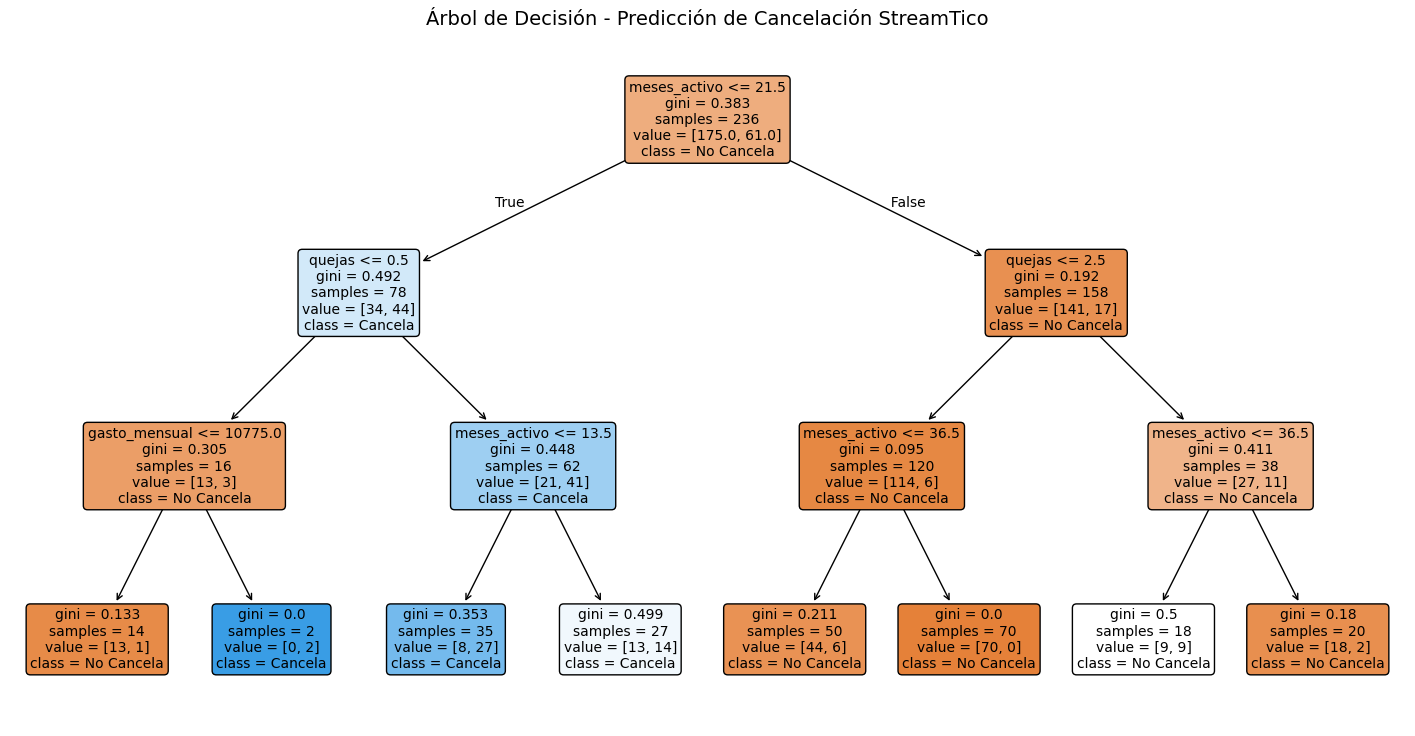


--- 9. EVALUACIÓN DEL MODELO ---
Exactitud (Accuracy): 81.67%

Matriz de Confusión:
[[42  9]
 [ 2  7]]

Reporte de Clasificación:
              precision    recall  f1-score   support

          No       0.95      0.82      0.88        51
          Sí       0.44      0.78      0.56         9

    accuracy                           0.82        60
   macro avg       0.70      0.80      0.72        60
weighted avg       0.88      0.82      0.84        60


--- 10. PREDICCIÓN EN CLIENTES NUEVOS ---
Resultados finales para la hoja 'clientes_nuevos':


,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,Predicción Cancelación
0,NV-01,24,2,4,Básico,4750,Sí
1,NV-02,45,48,0,Premium,10900,No
2,NV-03,31,6,2,Estándar,7400,Sí
3,NV-04,58,30,1,Estándar,7900,No
4,NV-05,37,12,5,Básico,5250,Sí


In [1]:
# Frenny Montezuma Castillo
# Grupo 04

import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

print("1. Librerías cargadas correctamente.\n")

print("--- 2. CARGA DE ARCHIVO ---")
print("Por favor, selecciona y sube el archivo 'clientes_streamtico.xlsx':")
uploaded = files.upload()

nombre_archivo = list(uploaded.keys())[0]

df_clientes = pd.read_excel(nombre_archivo, sheet_name='clientes')
df_nuevos = pd.read_excel(nombre_archivo, sheet_name='clientes_nuevos')
df_diccionario = pd.read_excel(nombre_archivo, sheet_name='diccionario')

print("\nArchivo cargado con éxito.")

print("\n--- 3. EXPLORACIÓN INICIAL DE DATOS ---")
print("Primeras 5 filas del historial de clientes:")
display(df_clientes.head())

print("\nEstructura y tipos de datos:")
df_clientes.info()

print("\nValores nulos detectados por columna:")
print(df_clientes.isnull().sum())

print(f"\nFilas duplicadas identificadas: {df_clientes.duplicated().sum()}")

print("\nResumen estadístico de variables numéricas:")
display(df_clientes.describe())

print("\nValores únicos en columnas de texto:")
for col in ['plan', 'gasto_mensual', 'cancelo']:
    if col in df_clientes.columns:
        print(f"Columna '{col}': {df_clientes[col].unique()}")

tabla_errores = pd.DataFrame({
    'N° Error': range(1, 11),
    'Columna Afectada': [
        'Varias / Historial',
        'meses_activo',
        'cancelo',
        'plan',
        'cancelo',
        'gasto_mensual',
        'edad',
        'meses_activo',
        'quejas',
        'encuesta_salida',
    ],
    'Cómo se detectó (Código)': [
        "df_clientes.duplicated().sum()",
        "df_clientes['meses_activo'].isnull().sum()",
        "df_clientes['cancelo'].isnull().sum()",
        "df_clientes['plan'].value_counts()",
        "df_clientes['cancelo'].value_counts()",
        "df_clientes['gasto_mensual'].unique()",
        "df_clientes[(df['edad'] < 18) | (df['edad'] > 100)]",
        "df_clientes[df_clientes['meses_activo'] > 60]",
        "df_clientes[df_clientes['quejas'] < 0]",
        "Incoherencias / Nulos irrelevantes",
    ],
    'Cómo se corrigió': [
        'Se eliminaron las filas repetidas con drop_duplicates().',
        'Se imputaron los 7 vacíos con la mediana del grupo.',
        'Se eliminaron las 4 filas con la variable objetivo nula.',
        'Se unificaron errores tipográficos, mayúsculas y espacios.',
        'Se estandarizaron variantes como Si, si, NO, no a "Sí" y "No".',
        'Se eliminó el símbolo "₡" y comas, convirtiendo a número.',
        'Se reemplazaron valores fuera de rango (-4, 0, 250) por la mediana.',
        'Se reemplazaron valores fuera de rango (360, 480, 999) por la mediana.',
        'Se corrigieron valores negativos (< 0) ajustándolos a 0.',
        'Se descartó la columna para el modelo por ser posterior a la cancelación.',
    ],
})

print("\n--- 4. DETECCIÓN DE LOS 10 ERRORES INTENCIONALES ---")
display(tabla_errores)

print("\n--- 5. LIMPIEZA AUTOMATIZADA DE DATOS ---")
df_limpio = df_clientes.copy()

df_limpio = df_limpio.drop_duplicates()

df_limpio = df_limpio.dropna(subset=['cancelo'])

df_limpio['cancelo'] = (
    df_limpio['cancelo']
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace({'Si': 'Sí', 'No': 'No'})
)

df_limpio['gasto_mensual'] = (
    df_limpio['gasto_mensual']
    .astype(str)
    .str.replace('₡', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

df_limpio['plan'] = (
    df_limpio['plan']
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace({
        'Basico': 'Básico',
        'Estandar': 'Estándar',
        'Premium': 'Premium',
    })
)

mediana_edad = df_limpio.loc[
    (df_limpio['edad'] >= 18) & (df_limpio['edad'] <= 100), 'edad'
].median()
df_limpio.loc[
    (df_limpio['edad'] < 18) | (df_limpio['edad'] > 100), 'edad'
] = np.nan
df_limpio['edad'] = df_limpio['edad'].fillna(mediana_edad)

mediana_meses = df_limpio.loc[
    (df_limpio['meses_activo'] >= 1) & (df_limpio['meses_activo'] <= 60),
    'meses_activo',
].median()
df_limpio.loc[
    (df_limpio['meses_activo'] < 1) | (df_limpio['meses_activo'] > 60),
    'meses_activo',
] = np.nan
df_limpio['meses_activo'] = df_limpio['meses_activo'].fillna(mediana_meses)

df_limpio.loc[df_limpio['quejas'] < 0, 'quejas'] = 0

print(f"Filas restantes tras la limpieza: {len(df_limpio)}")
print("Confirmación de valores nulos pendientes en las variables clave:")
print(
    df_limpio[[
        'edad',
        'meses_activo',
        'quejas',
        'plan',
        'gasto_mensual',
        'cancelo',
    ]].isnull().sum()
)

print("\n--- 6. DEFINICIÓN DE X Y Y ---")

X = pd.get_dummies(
    df_limpio[['edad', 'meses_activo', 'quejas', 'plan', 'gasto_mensual']],
    columns=['plan'],
    drop_first=False,
)

y = df_limpio['cancelo'].map({'No': 0, 'Sí': 1})

print("Variables independientes (X) preparadas:")
display(X.head())

print("\n--- 7. DIVISIÓN EN TRAIN (80%) Y TEST (20%) ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

print("\n--- 8. ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN ---")
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arbol.fit(X_train, y_train)

plt.figure(figsize=(18, 9))
plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=['No Cancela', 'Cancela'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title(
    "Árbol de Decisión - Predicción de Cancelación StreamTico", fontsize=14
)
plt.show()

print("\n--- 9. EVALUACIÓN DEL MODELO ---")
y_pred = modelo_arbol.predict(X_test)
exactitud = accuracy_score(y_test, y_pred)

print(f"Exactitud (Accuracy): {exactitud * 100:.2f}%\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No', 'Sí']))

print("\n--- 10. PREDICCIÓN EN CLIENTES NUEVOS ---")

df_nuevos_prep = df_nuevos[
    ['edad', 'meses_activo', 'quejas', 'plan', 'gasto_mensual']
].copy()
df_nuevos_prep['gasto_mensual'] = (
    df_nuevos_prep['gasto_mensual']
    .astype(str)
    .str.replace('₡', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)
df_nuevos_prep = pd.get_dummies(
    df_nuevos_prep, columns=['plan'], drop_first=False
)

for col in X.columns:
    if col not in df_nuevos_prep.columns:
        df_nuevos_prep[col] = 0
df_nuevos_prep = df_nuevos_prep[X.columns]

predicciones_nuevos = modelo_arbol.predict(df_nuevos_prep)
df_nuevos['Predicción Cancelación'] = [
    'Sí' if p == 1 else 'No' for p in predicciones_nuevos
]

print("Resultados finales para la hoja 'clientes_nuevos':")
display(
    df_nuevos[[
        'id_cliente',
        'edad',
        'meses_activo',
        'quejas',
        'plan',
        'gasto_mensual',
        'Predicción Cancelación',
    ]]
)


## 11. CONCLUSIONES Y RECOMENDACIONES
CONCLUSIÓN:
De acuerdo con el árbol de decisión entrenado, los clientes propensos a cancelar son principalmente
aquellos con poca antigüedad en la plataforma (meses_activo ≤ 21.5) que ya registran quejas en el
servicio, o bien clientes nuevos que asumen un costo mensual elevado (> ₡10,775) sin haberse afianzado
aún con la plataforma.

RECOMENDACIÓN PARA STREAMTICO:
1. Implementar un protocolo de acompañamiento y seguimiento prioritario en soporte para clientes en sus
   primeros 6 a 12 meses de suscripción cuando registren su primera queja.
2. Crear promociones o descuentos de bienvenida durante el primer año para reducir el impacto financiero
   del gasto mensual en los planes más costosos.